## Imports

In [21]:
from sklearn.datasets        import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics         import accuracy_score
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import confusion_matrix
from sklearn.tree            import DecisionTreeClassifier
from sklearn.tree            import plot_tree
from sklearn.ensemble        import RandomForestClassifier

import matplotlib.pyplot as plt

## Inspeção inicial do dados

Como os dados já vem no formato de um objeto, pronto para uso em ML, não serão necessárias etapas de análise e tratamento de dados (Pandas).

Porém, é possível investigar algumas características à respeito desses dados.

In [22]:
dados_iris = load_iris()
dados_iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [23]:
dados_iris.data.shape

(150, 4)

In [24]:
dados_iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [25]:
dados_iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [26]:
dados_iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [27]:
print(dados_iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Pelas informações obtidas acima, conclúi-se que:

- Existem 4 features para as flores: comprimento da sépala, largura da sépala, comprimento da pétala, largura da pétala
- Há um conjunto de 150 amostras de flores, que contém as 4 features avaliadas
- Existe 1 target (variável que deseja-se prever), que pode ser de 3 tipos (as espécies de flor): Iris setosa, Iris versicolour, Iris virginica
- Deseja-se detectar qual espécie de flor aquela amostra pertence

Esse caso constitui, portanto, um problema de 'classificação' (objetivo é prever uma categoria/classe), multiclasse, pois são as 3 espécies de Iris.

Com isso, podemos filtrar os modelos que podem ser aplicados. Para esse projeto, serão utilizados:
- Regressão logística
- Árvore de decisão
- Random forest

E ao final serão comparados os resultados de cada um.

In [28]:
x = dados_iris.data   # features (características da flor)
y = dados_iris.target # target (espécie)

x_treino, x_teste, y_treino, y_teste = train_test_split(
    x, 
    y, 
    test_size=0.2, 
    random_state=50
)

## Regressão logística

In [29]:
modelo_rl = LogisticRegression()
modelo_rl.fit(x_treino, y_treino)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
modelo_rl.coef_

array([[-0.42732499,  0.94196626, -2.37399786, -1.01230009],
       [ 0.39422493, -0.2485476 , -0.15621586, -0.85208886],
       [ 0.03310005, -0.69341866,  2.53021372,  1.86438895]])

| classe       | largura sépala | comp. sépala | largura pétala | comp. pétala |
|--------------|----------------|--------------|----------------|--------------|
| setosa       | -0.4273        |  0.9420      | -2.3740        | -1.0123      |
| versicolor   |  0.3942        | -0.2485      | -0.1562        | -0.8521      |
| virginica    |  0.0331        | -0.6934      |  2.5302        |  1.8644      |

A matriz contém os coeficientes aprendidos pela regressão logística.

Cada valor indica o peso de uma feature na decisão do modelo para classificar uma flor em determinada espécie. Valores positivos aumentam a pontuação da classe, enquanto valores negativos a reduzem.

Por exemplo, as features largura e comprimento da pétala (de valores 2.53 e 1.86 respectivamente) do 3º array tem valores positivos significativos, em relação as outras 2 características; Elas são, portanto, mais relevantes para a classificação dessa espécie.

In [31]:
previsoes_rl = modelo_rl.predict(x_teste)
print(previsoes_rl)

[1 1 0 0 2 2 2 0 0 1 0 2 0 2 1 0 1 0 1 2 2 1 0 2 1 2 1 1 1 2]


In [32]:
acuracia_rl = accuracy_score(y_teste, previsoes_rl) * 100
print(f"Acurácia: {acuracia_rl:.2f} %")

Acurácia: 96.67 %


Observamos que a acurácia do teste (com amostras nunca antes vistas pelo modelo) foi alta. Porém, isso é esperado, pois o dataset das Iris é relativamente pequeno e simples.

In [33]:
confusion_matrix(y_teste, previsoes_rl)

array([[ 9,  0,  0],
       [ 0, 11,  1],
       [ 0,  0,  9]])

| real\prev | espécie 1 | espécie 2 | espécie 3 |
| ----------|-----------|-----------|-----------|
| espécie 1 |     9     |     0     |     0     |
| espécie 2 |     0     |    11     |     1     |
| espécie 3 |     0     |     0     |     9     |

A confusion matrix mostra como o modelo classificou as espécies, indicando as classificações corretas e erradas do modelo.

Por exemplo, houve 1 classificação errada da espécie 2, que o modelo classificou como espécie 3.

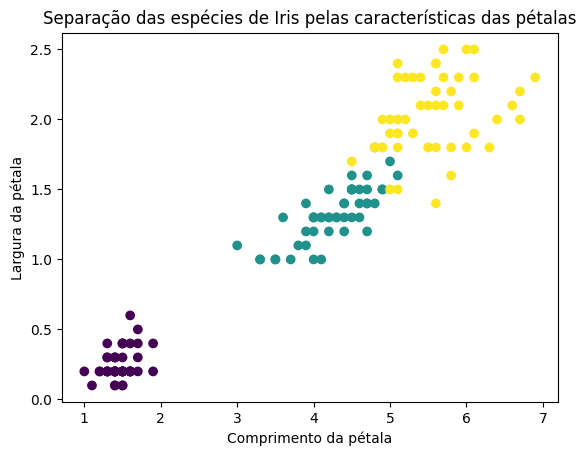

In [34]:
plt.scatter(x[:,2], x[:,3], c=y)
plt.xlabel("Comprimento da pétala")
plt.ylabel("Largura da pétala")
plt.title("Separação das espécies de Iris pelas características das pétalas")
plt.show()

No gráfico acima, os pontos representam indivíduos das espécies. As 3 cores indicam as 3 diferentes espécies.

É notável que as Iris da espécie 1 possuem baixo comprimento (~ 1-2cm) e largura (~ 0.1-0.5cm) de pétala, e tem uma distribuição mais uniforme em relação às outras.
A espécie 2 possui características intermediárias de largura e comprimento das pétalas, e a espécie 3 tem dimensões maiores, mas também tem uma distribuição mais dispersa.

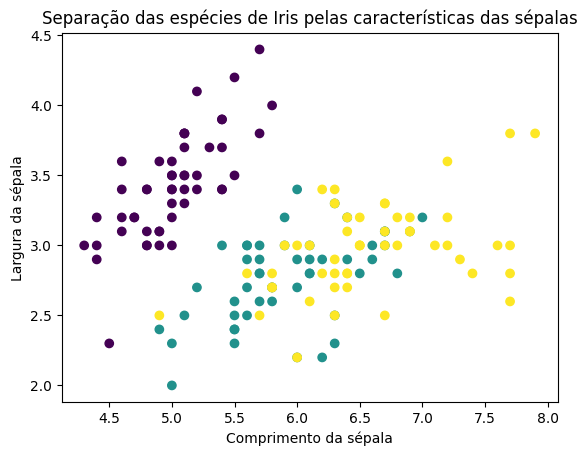

In [35]:
plt.scatter(x[:,0], x[:,1], c=y)
plt.xlabel("Comprimento da sépala")
plt.ylabel("Largura da sépala")
plt.title("Separação das espécies de Iris pelas características das sépalas")
plt.show()

Já neste outro gráfico, de distribuição das amostras com base em características da sépala, é possível notar uma clara diferença em relação ao outro gráfico.

A sépala não é tão relevante na caracterização da espécie tal como a pétala. A distribuição de todas as 3 espécies ficou muito esparsa, dificultando uma caracterização clara da espécie com base nas dimensões da sépala.

## Árvore de decisão

In [43]:
modelo_arvore = DecisionTreeClassifier()
modelo_arvore.fit(x_treino, y_treino)
previsoes_arvore = modelo_arvore.predict(x_teste)
acuraria_arvore = accuracy_score(y_teste, previsoes_arvore) * 100
print(f"Acurárica do modelo: {acuraria_arvore:.2f} %")

Acurárica do modelo: 96.67 %


A acurácia nesse modelo também foi bem alta, assim como no modelo anterior.

In [37]:
modelo_arvore.get_depth()

5

In [38]:
modelo_arvore.get_n_leaves()

np.int64(8)

A profundidade da árvore está relacionada à complexidade do modelo: árvores muito profundas tendem a se ajustar excessivamente aos dados de treino (overfitting), enquanto árvores mais rasas tendem a generalizar melhor.

Neste caso, a árvore possui profundidade 5, o que é relativamente baixo, indicando que o problema de classificação do dataset Iris pode ser resolvido com poucas regras de decisão.

[Text(0.4, 0.9166666666666666, 'petal width (cm) <= 0.8\ngini = 0.666\nsamples = 120\nvalue = [41, 38, 41]\nclass = setosa'),
 Text(0.3, 0.75, 'gini = 0.0\nsamples = 41\nvalue = [41, 0, 0]\nclass = setosa'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'petal width (cm) <= 1.65\ngini = 0.499\nsamples = 79\nvalue = [0, 38, 41]\nclass = virginica'),
 Text(0.45, 0.8333333333333333, '  False'),
 Text(0.2, 0.5833333333333334, 'petal length (cm) <= 4.95\ngini = 0.176\nsamples = 41\nvalue = [0, 37, 4]\nclass = versicolor'),
 Text(0.1, 0.4166666666666667, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]\nclass = versicolor'),
 Text(0.3, 0.4166666666666667, 'petal width (cm) <= 1.55\ngini = 0.32\nsamples = 5\nvalue = [0, 1, 4]\nclass = virginica'),
 Text(0.2, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]\nclass = virginica'),
 Text(0.4, 0.25, 'petal length (cm) <= 5.45\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]\nclass = versicolor'),
 Text(0.3, 0.08333333333333333, 'gini = 0.0\

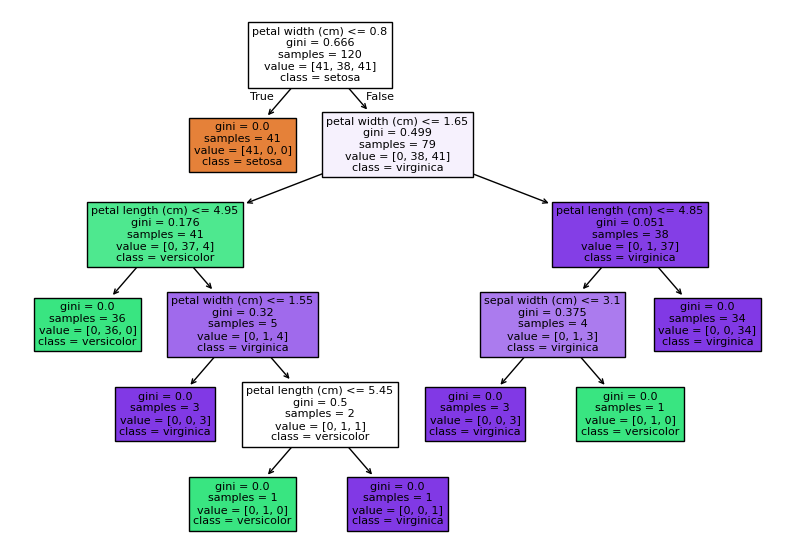

In [41]:
plt.figure(figsize=(10,7))
plot_tree(
    modelo_arvore,
    feature_names=dados_iris.feature_names,
    class_names=dados_iris.target_names,
    filled=True
)

A árvore de decisão mostrou que a variável mais relevante para a classificação é a largura da pétala. Um único corte nessa variável já separa perfeitamente a espécie setosa das demais. 

As espécies versicolor e virginica exigem divisões adicionais, principalmente com base no comprimento da pétala.